# Exercise 2: Bathymetry

**Aim:** To work with bathymetry data and plot contour figures

**Your Information (EDIT THIS SECTION):**
- Author: James Bamber
- Purpose: Plot bathymetry data
- Date: 23rd April 2026

**Required Outputs:**
Three figures should be generated:
- ex2fig1-YourName-Messfern.png: (matplotlib) Map of bathymetry
- ex2fig2-YourName-Messfern.png: (cartopy) Second map of bathymetry
- ex2fig3-YourName-Messfern.png: (cartopy) Enhanced cartopy map

**Required Packages:** You will need `netCDF4`, `cartopy`, and optionally `cmocean` for better color scales.

---

**Complete your information here:**

- **Your Name:** James Bamber
- **Date:** 23rd April, 2026
- **Student ID:** 7731306

**Replace the placeholder text above with your actual information.**

## Importing Required Packages

In [1]:
# Importing required packages here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import os
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Optional: cmocean for better ocean color scales
try:
    import cmocean
    print("✓ cmocean available for better ocean color scales")
except ImportError:
    print("⚠️  cmocean not available - using matplotlib defaults")

from matplotlib.ticker import ScalarFormatter

# Import modules from the local modules directory
# The notebook is in src/, so modules is at ../modules/
import sys
sys.path.append('..')
from modules import *

✓ cmocean available for better ocean color scales


## File Paths Setup

In [2]:
# Set paths relative to the current notebook location
datadir = '../data/'

# Output file paths for figures (DO NOT CHANGE THIS PATH)
# The autograder expects figures to be saved in '../figures/'
figdir = '../figures/'

# Create figures directory if it doesn't exist
if not os.path.exists(figdir):
    os.makedirs(figdir)
    
print(f"Figures will be saved to: {figdir}")
print(f"Data directory: {datadir}")

Figures will be saved to: ../figures/
Data directory: ../data/


In [3]:
# Test that setup is complete
assert 'figdir' in locals(), "figdir variable not defined"
assert figdir.endswith('/'), "figdir should end with '/'"
# Note: datadir will be created by download function, so we don't test for existence here
assert 'datadir' in locals(), "datadir variable not defined"
print("✓ File setup test passed!")

✓ File setup test passed!


## Load the Bathymetry Data

We'll load real bathymetry data from the provided NetCDF file, which contains a subset of ETOPO bathymetry data for the North Atlantic region.

In [4]:
# YOUR CODE HERE
# Load the bathymetry subset data from the NetCDF file.
# Use the `get_bathymetry_subset_from_url()` function from the bathymetry module to download
# the bathymetry_subset.nc file if it does not already exist in the data directory.  The output of this
# function is the path to the downloaded NetCDF file, which you can call `bathymetry_file_path`.
bathymetry_file_path = get_bathymetry_subset_from_url('data/bathymetry_subset.nc')

# Use xr.open_dataset() to load the bathymetry_subset.nc file from the data directory.  Use the input to
# xr.open_dataset() as the path to the bathymetry_subset.nc file obtained from the previous step.  Name the 
# data variable `bathymetry_subset`.
# The dataset should contain latitude, longitude, and depth (z) variables
bathymetry_subset = xr.open_dataset(bathymetry_file_path)

# Print information about the dataset
print(bathymetry_subset)
#bathymetry_subset.info

<xarray.Dataset> Size: 435kB
Dimensions:  (lat: 180, lon: 600)
Coordinates:
  * lat      (lat) float32 720B 63.01 63.03 63.04 63.06 ... 65.96 65.97 65.99
  * lon      (lon) float32 2kB -34.99 -34.97 -34.96 ... -25.04 -25.02 -25.01
Data variables:
    z        (lat, lon) float32 432kB ...


In [5]:
# Test that bathymetry data was created correctly
assert 'bathymetry_subset' in locals(), "bathymetry_subset not defined"
assert 'z' in bathymetry_subset.data_vars, "z variable not found in dataset"
assert bathymetry_subset.z.max() <= 0, "Bathymetry should have negative depths"
assert bathymetry_subset.z.min() >= -5000, "Depths seem unreasonably deep"
print("✓ Bathymetry data creation test passed!")

✓ Bathymetry data creation test passed!


## Writing Your First Function

Now that we have loaded the bathymetry data, let's learn to write a **function**! Functions are reusable pieces of code that take inputs, do something useful, and return results.

We'll write a function to extract the water depth at any location. This will be useful for finding depths at specific points like the DS2 mooring location.

In [ ]:
# YOUR CODE HERE
# Write a function to extract water depth at a specific location
def get_depth_at_location(bathymetry_dataset, target_lat, target_lon):
    """
    Extract water depth at a specific location.
    
    Parameters:
    - bathymetry_dataset: xarray Dataset with lat, lon, z variables
    - target_lat: Target latitude (degrees North)  
    - target_lon: Target longitude (degrees East, negative for West)
    
    Returns:
    - depth: Water depth at location (meters, negative below sea level)
    """
    depth_value = bathymetry_dataset.z.sel(lat=target_lat, lon=target_lon, method='nearest')
    
    if hasattr(depth_value, 'item'):
        return depth_value.item()
    else:
        return float(depth_value.values)

# Test your function with the DS2 mooring location
ds2_latitude = 66.0128
ds2_longitude = -27.270200

# Call your function to get the depth at DS2 mooring
ds2_depth = get_depth_at_location(bathymetry_subset, ds2_latitude, ds2_longitude)
print(f"Water depth at DS2 mooring ({ds2_latitude}°N, {ds2_longitude}°E): {ds2_depth:.1f} m")

Water depth at DS2 mooring (66.0128°N, -27.2702°E): -649.8 m


In [7]:
# Test that your function works correctly
assert 'get_depth_at_location' in locals(), "Function get_depth_at_location not defined"
assert callable(get_depth_at_location), "get_depth_at_location should be a function"

# Test that the function returns a reasonable depth value
test_depth = get_depth_at_location(bathymetry_subset, 64.5, -30.0)
assert isinstance(test_depth, (int, float)), "Function should return a number"
assert test_depth < 0, "Ocean depths should be negative (below sea level)"
assert test_depth > -5000, "Depth seems unreasonably deep"

print("✓ Function test passed!")
print(f"✓ DS2 depth: {ds2_depth:.1f} m")

✓ Function test passed!
✓ DS2 depth: -649.8 m


## Make a Simple Plot

### Using Matplotlib

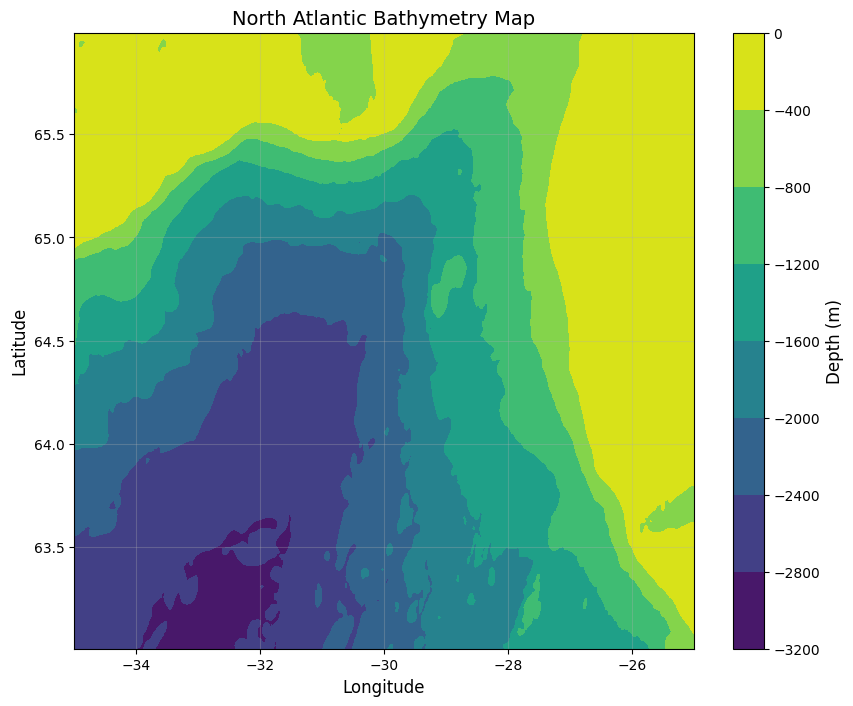

In [12]:
# Extract the latitude, longitude, and bathymetry data
lats = bathymetry_subset.lat.values
lons = bathymetry_subset.lon.values
bathymetry = bathymetry_subset.z.values

# Use plt.figure() to create a figure with appropriate size (10, 8)
plt.figure(figsize=(10, 8))

# Create meaningful depth contours at 500m intervals
depth_levels = np.arange(-4000, 1000, 500)  # From -4000m to 0m in 500m steps

# Choose appropriate colormap
cmap = 'viridis'

# YOUR CODE HERE
# Create a contour plot using matplotlib
# Use plt.contourf() to create filled contours
contour = plt.contourf(lons,lats,bathymetry)

# Add colorbar, labels, title, and grid

# Add colorbar
cbar = plt.colorbar(contour)
cbar.set_label('Depth (m)', fontsize=12)

# Add labels and title
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('North Atlantic Bathymetry Map', fontsize=14)

# Add grid
plt.grid(True, alpha=0.3)

# Format axes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Save the figure
# IMPORTANT: Change 'YourName' to your actual last name
plt.savefig(figdir + 'ex2fig1-Bamber-Messfern.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Test that Figure 1 was created correctly
import glob
fig1_files = glob.glob(figdir + 'ex2fig1-*-Messfern.png')
assert len(fig1_files) > 0, "Figure 1 (ex2fig1-YourName-Messfern.png) was not created"
for fig_file in fig1_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 1 test passed: {fig1_files[0]}")

✓ Figure 1 test passed: ../figures/ex2fig1-Bamber-Messfern.png


### Plot a Map using Cartopy

See how the example code uses the cartopy capability to choose a Mercator projection.

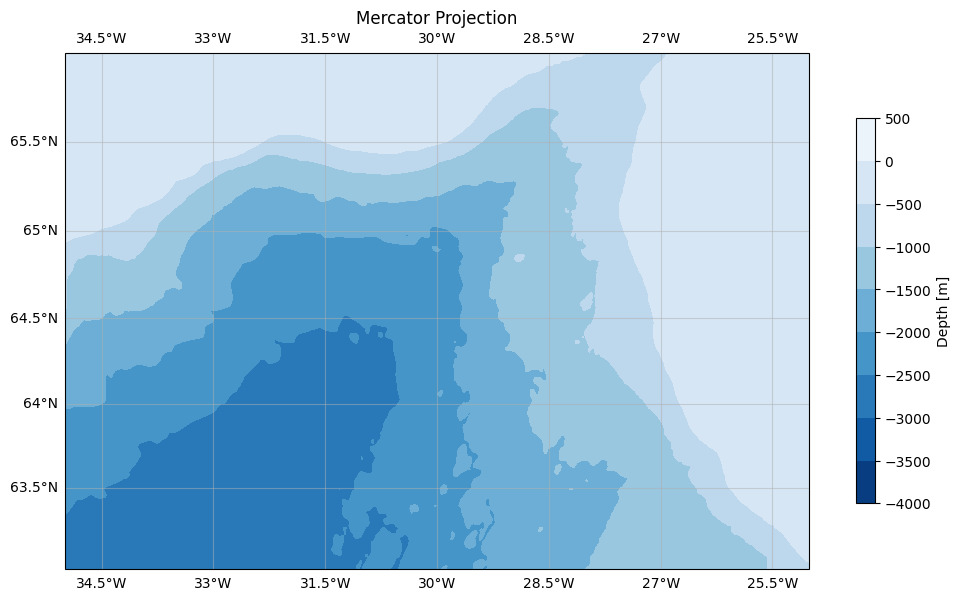

In [26]:
# Define geographic extent
min_lon, max_lon = lons.min(), lons.max()
min_lat, max_lat = lats.min(), lats.max()

# Set up with a Mercator projection
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.Mercator()})

# Add coastlines and gridlines
ax.coastlines(resolution='50m', color='black', linewidth=0.8)
gl = ax.gridlines(draw_labels=True, alpha=0.5)
gl.top_labels = True
gl.right_labels = False

# Set the extent
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())



# YOUR CODE HERE
# Create an enhanced cartopy map with the following features:
# 1. Pick depth levels with an interval of 500m (depth_levels)
# 2. Use better colormap (cmap=cmocean.cm.deep if available, otherwise `Blues` or `Blues_r`)
# 3. Turn off latitude labels on the right side (edit the code above)
# 4. Label the colorbar with Depth (m)
# 5. Add a title to specify that this used "Mercator Projection"
#raise NotImplementedError()
cmap = 'Blues_r'
plt.title('Mercator Projection')
contour = ax.contourf(lons, lats, bathymetry, levels=depth_levels, 
                     cmap=cmap, transform=ccrs.PlateCarree())
# Add colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', 
                   pad=0.05, aspect=20, shrink=0.5, label = 'Depth [m]')

# Save the figure
# IMPORTANT: Change 'YourName' to your actual last name
plt.savefig(figdir + 'ex2fig2-Bamber-Messfern.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Test that Figure 2 was created correctly
fig2_files = glob.glob(figdir + 'ex2fig2-*-Messfern.png')
assert len(fig2_files) > 0, "Figure 2 (ex2fig2-YourName-Messfern.png) was not created"
for fig_file in fig2_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 2 test passed: {fig2_files[0]}")

✓ Figure 2 test passed: ../figures/ex2fig2-Bamber-Messfern.png


## Enhanced Cartopy Map with Annotations

Now edit the maps - work with the cartopy version and add the following features:

- Add a single point location using a circle for the DS2 mooring (66.0128 latitude, -27.270200 longitude)
- Add a legend that specifies "DS2 mooring" for the circle
- Turn off latitude markers on the right hand side of the plot
- Change the color scale to something appropriate for bathymetry (use cmocean if available)
- Crop the bathymetry so that it fills a region with aspect ratio 16 x 26 cm, then resize the figure

**Extra challenge:** Mark the deepest point on the map with a square

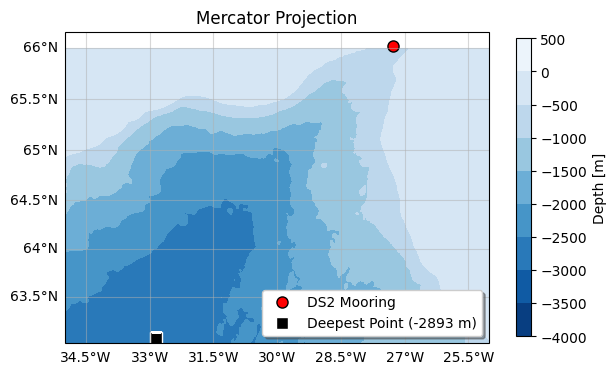

Deepest point found at: 63.058°N, -32.842°W
Depth: -2893.3 m


In [50]:
# Define DS2 mooring location
ds2_lat = 66.0128
ds2_lon = -27.270200

# Convert cm to inches (16cm x 26cm)
fig_width_inches = 16 / 2.54
fig_height_inches = 26 / 2.54

# Find the deepest point
deepest_idx = np.unravel_index(np.argmin(bathymetry), bathymetry.shape)
deepest_lat = lats[deepest_idx[0]]
deepest_lon = lons[deepest_idx[1]]
deepest_depth = bathymetry[deepest_idx]

# YOUR CODE HERE
# Create an enhanced cartopy map with the following features:
# 1. Use appropriate figure size (16cm x 26cm converted to inches)
# 2. Add DS2 mooring location (66.0128°N, -27.270200°W) as a circle
# 3. Add legend for the mooring
# 4. Use better colormap (as above, cmocean or Blues/Blues_r)
# 5. Turn off latitude labels on the top and right side
# 6. Find and mark the deepest point with a square


fig, ax = plt.subplots(figsize=(fig_width_inches, fig_height_inches), 
                       subplot_kw={'projection': ccrs.Mercator()})

cmap = 'Blues_r'
plt.title('Mercator Projection')
contour = ax.contourf(lons, lats, bathymetry, levels=depth_levels, 
                     cmap=cmap, transform=ccrs.PlateCarree())
# Add colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', 
                   pad=0.05, aspect=20, shrink=0.3, label = 'Depth [m]')

ds2_plot = ax.plot(
    ds2_lon, ds2_lat, 'o', markersize=8,
    color='red', transform=ccrs.PlateCarree(),
    label='DS2 Mooring', markeredgecolor='black'
)

deepest_plot = ax.plot(deepest_lon, deepest_lat, 'ks', markersize=8, 
                      transform=ccrs.PlateCarree(), 
                      label=f'Deepest Point ({deepest_depth:.0f} m)',
                      markeredgecolor='white', markeredgewidth=1)

# Add legend - check options to see what to use for frameon, fancybox, shadow
ax.legend(loc='lower right', 
          frameon = True, 
          fancybox= True,
          shadow= True)

ax.coastlines(resolution='50m', color='black', linewidth=0.8)
gl = ax.gridlines(draw_labels=True, alpha=0.5)
gl.top_labels = False
gl.right_labels = False


# Adjust layout for better appearance
plt.tight_layout()

# Save the figure
# IMPORTANT: Change 'YourName' to your actual last name
plt.savefig(figdir + 'ex2fig3-Bamber-Messfern.png', dpi=150, bbox_inches='tight')
plt.show()


print(f"Deepest point found at: {deepest_lat:.3f}°N, {deepest_lon:.3f}°W")
print(f"Depth: {deepest_depth:.1f} m")

In [51]:
# Test that Figure 3 was created correctly
fig3_files = glob.glob(figdir + 'ex2fig3-*-Messfern.png')
assert len(fig3_files) > 0, "Figure 3 (ex2fig3-YourName-Messfern.png) was not created"
for fig_file in fig3_files:
    assert 'YourName' not in fig_file, f"Replace 'YourName' with your actual name in: {fig_file}"
print(f"✓ Figure 3 test passed: {fig3_files[0]}")

✓ Figure 3 test passed: ../figures/ex2fig3-Bamber-Messfern.png


## Analysis Questions

**Question 1:** Compare the matplotlib and cartopy versions of your bathymetry maps (Figures 1 and 2). What are the advantages of using cartopy for geospatial data visualization?

**Question 2:** Explain the purpose of using different map projections when plotting bathymetry data. Why might Mercator projection be suitable for this North Atlantic region?

**Question 3:** Based on the bathymetry patterns you observe, describe the seafloor topography in your mapped region. What oceanographic features might be present?

**YOUR ANSWERS HERE:**

1. [Your answer for Question 1]

2. [Your answer for Question 2]

3. [Your answer for Question 3]

In [ ]:
# Test that analysis questions were answered
# This is a placeholder test - manual grading required for analysis questions
print("✓ Analysis questions section present - manual grading required")